In [65]:
# let's import

In [66]:
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split,GridSearchCV

from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score,classification_report
import matplotlib.pyplot as plt
import seaborn as sns

import warnings 
warnings.filterwarnings('ignore')

In [67]:
data = pd.read_csv(r"D:\wine.csv")
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Alcohol_content,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,Low,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,Medium,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,Medium,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,Medium,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,Low,5


In [68]:
data.sample(n=10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Alcohol_content,quality
348,9.6,0.560,0.31,2.8,0.089,15.0,46.0,0.99790,3.11,0.92,10.0,Medium,6
996,5.6,0.660,0.00,2.2,0.087,3.0,11.0,0.99378,3.71,0.63,12.8,High,7
1087,7.9,0.190,0.42,1.6,0.057,18.0,30.0,0.99400,3.29,0.69,11.2,High,6
832,10.4,0.440,0.42,1.5,0.145,34.0,48.0,0.99832,3.38,0.86,9.9,Medium,3
515,8.5,0.655,0.49,6.1,0.122,34.0,151.0,1.00100,3.31,1.14,9.3,Low,5
395,12.0,0.370,0.76,4.2,0.066,7.0,38.0,1.00040,3.22,0.60,13.0,High,7
184,6.7,0.620,0.21,1.9,0.079,8.0,62.0,0.99700,3.52,0.58,9.3,Low,6
1318,7.5,0.630,0.27,2.0,0.083,17.0,91.0,0.99616,3.26,0.58,9.8,Medium,6
1011,8.9,0.320,0.31,2.0,0.088,12.0,19.0,0.99570,3.17,0.55,10.4,Medium,6
1420,7.8,0.530,0.01,1.6,0.077,3.0,19.0,0.99500,3.16,0.46,9.8,Medium,5


In [69]:
data.shape

(1599, 13)

In [70]:
# Any misssing values?
data.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
Alcohol_content         0
quality                 0
dtype: int64

# As we have categorical column (Alcohol_Content), We need to convert into numeric data using encoding method.

In [71]:
from sklearn.preprocessing import OrdinalEncoder

In [72]:
ord_encoder = OrdinalEncoder(categories=[['Low','Medium','High']])
df1=ord_encoder.fit_transform(data[['Alcohol_content']])
df1

array([[0.],
       [1.],
       [1.],
       ...,
       [2.],
       [1.],
       [2.]])

# override alcohol content column with codes

In [73]:
data['Alcohol_content']=df1
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Alcohol_content,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0.0,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,1.0,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,1.0,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,1.0,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0.0,5


# Plotting Heatmap (Correlation matrix)

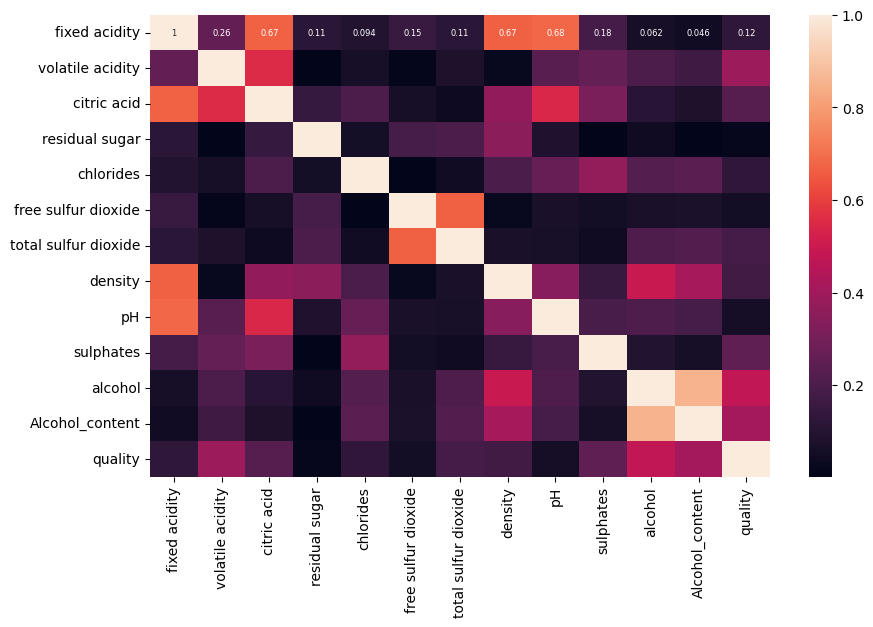

In [74]:
df_corr = data.corr().abs()# This code will get the coefficient of one variable vs all other variable (relationship)
plt.figure(figsize=(10,6))
sns.heatmap(df_corr,annot=True, annot_kws={'size':6})
plt.show()

# Make sure they are really correlated(It should follow some trend)

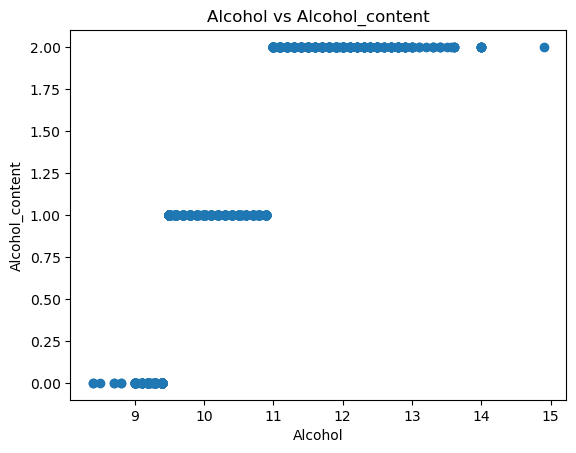

In [75]:
plt.scatter(data.alcohol, data.Alcohol_content)
plt.xlabel('Alcohol')
plt.ylabel('Alcohol_content')
plt.title('Alcohol vs Alcohol_content')
plt.show()

We see clear trend.when alcohol level increases it's content also increasing. so we can delete one of them.

In [76]:
x = data.drop(columns = ['quality','Alcohol_content'])
y = data['quality']

In [77]:
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.25, random_state = 41)

In [78]:
# Write one function and call as many as times to check accuracy_score of different models
def metric_score(clf,x_train,x_test,y_train,y_test, train=True):
    if train:
        y_pred = clf.predict(x_train)
        print("\n=====================Train Result=========================")
        print(f"Accuracy Score: {accuracy_score(y_train,y_pred) * 100:.2f}%")

    elif train==False:
        pred = clf.predict(x_test)
        print("\n=====================Test Result==========================")
        print(f"Accuracy Score: {accuracy_score(y_test,pred) * 100:.2f}%")
        print ('\n \n Test Classification Report \n', classification_report(y_test, pred,digits=2))

In [79]:
# Model initiation
clf = DecisionTreeClassifier()
clf.fit(x_train,y_train)

DecisionTreeClassifier()

In [80]:
# Call the function and pass dataset to check train and test score
metric_score(clf,x_train,x_test,y_train,y_test,train=True)  # this is for training score
metric_score(clf,x_train,x_test,y_train,y_test,train=False)  # this is for testing score



=====================Train Result=========================
Accuracy Score: 100.00%

=====================Test Result==========================
Accuracy Score: 62.50%

 
 Test Classification Report 
               precision    recall  f1-score   support

           3       0.50      0.33      0.40         3
           4       0.09      0.09      0.09        11
           5       0.69      0.69      0.69       157
           6       0.66      0.64      0.65       168
           7       0.53      0.54      0.53        57
           8       0.12      0.25      0.17         4

    accuracy                           0.62       400
   macro avg       0.43      0.42      0.42       400
weighted avg       0.63      0.62      0.63       400



# Let's understand confusion_matrix for multi class

In [81]:
# Prediction for confusion matrix
y_pred = clf.predict(x_test)

# Create confusion_matrix
confusion_matrix(y_test,y_pred)

array([[  1,   1,   1,   0,   0,   0],
       [  1,   1,   7,   2,   0,   0],
       [  0,   5, 108,  39,   5,   0],
       [  0,   4,  31, 108,  21,   4],
       [  0,   0,   8,  15,  31,   3],
       [  0,   0,   1,   0,   2,   1]], dtype=int64)

In [82]:
# Converting into DataFrame to understand this better
pd.DataFrame(confusion_matrix(y_test,y_pred), columns=['Q3','Q4','Q5','Q6','Q7','Q8'], index=['Q3','Q4','Q5','Q6','Q7','Q8'])

,Q3,Q4,Q5,Q6,Q7,Q8
Q3,1,1,1,0,0,0
Q4,1,1,7,2,0,0
Q5,0,5,108,39,5,0
Q6,0,4,31,108,21,4
Q7,0,0,8,15,31,3
Q8,0,0,1,0,2,1


# Let's how the tree looks like (This is nothing to do with algorithm/accuracy).It's just for visualization purpose.

In [83]:
feature_name=list(x.columns)
class_name = list(y_train.unique())
feature_name

['fixed acidity',
 'volatile acidity',
 'citric acid',
 'residual sugar',
 'chlorides',
 'free sulfur dioxide',
 'total sulfur dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol']

In [84]:
#!pip install sklearn
#!pip install pydotplus
#!pip install graphviz
#import os
#os.environ['PATH'] = os.environ['PATH']+';'+os.environ['CONDA_PREFIX']+r"\Library\bin\graphviz"

In [85]:
#import graphviz
from sklearn.tree import export_graphviz
from sklearn import tree
from IPython.display import Image
import pydotplus

ModuleNotFoundError: No module named 'pydotplus'

In [ ]:
# create a dot_file which stores the tree structure
dot_data = export_graphviz(clf,feature_names = feature_name,rounded = True,filled = True)

# Draw graph
graph = pydotplus.graph_from_dot_data(dot_data)
graph.write_png("myTree.png")
# Show graph
Image(graph.create_png())

In [91]:
# We are tuning four important hyperparameters right now, we are passing the different values for both parameters 
grid_param = {
    'criterion' : ['gini', 'entropy'],
    'max_depth':range(12,15),         # the maximum depth of the tree.
    'min_samples_leaf': range(2,4),   #the minimum number of samples required to be at a leaf node.
    'min_samples_split': range(3,6),  #the minimum number of samples required to split an internal node.
    'max_leaf_nodes': range(40,50)    #If none then unlimited number of leaf nodes.
}
    


In [92]:
grid_search = GridSearchCV(estimator=clf,
                           param_grid=grid_param,
                           cv=5)

In [95]:
grid_search.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': range(12, 15),
                         'max_leaf_nodes': range(40, 50),
                         'min_samples_leaf': range(2, 4),
                         'min_samples_split': range(3, 6)})

In [96]:
best_parameters = grid_search.best_params_
print(best_parameters)

{'criterion': 'gini', 'max_depth': 12, 'max_leaf_nodes': 47, 'min_samples_leaf': 2, 'min_samples_split': 4}


In [103]:
# Initiate DecisionTreeClassifier with new parameters and train
clf= DecisionTreeClassifier(criterion = 'gini',min_samples_split=3, max_depth= 10,min_samples_leaf =2,max_leaf_nodes= 90)

In [104]:
# Train the model
clf.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=10, max_leaf_nodes=90, min_samples_leaf=2,
                       min_samples_split=3)

In [105]:
# call the function and pass dataset to check train and test score
metric_score(clf,x_train,x_test,y_train,y_test,train=True)   # This is for training score
metric_score(clf,x_train,x_test,y_train,y_test,train=False) # this is for testing score



=====================Train Result=========================
Accuracy Score: 80.73%

=====================Test Result==========================
Accuracy Score: 62.25%

 
 Test Classification Report 
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00        11
           5       0.64      0.76      0.69       157
           6       0.65      0.60      0.62       168
           7       0.59      0.51      0.55        57
           8       0.00      0.00      0.00         4

    accuracy                           0.62       400
   macro avg       0.31      0.31      0.31       400
weighted avg       0.61      0.62      0.61       400



In [107]:
# Prediction for confusion matrix
y_pred = clf.predict(x_test)

# converting into dataframe to understand this better
pd.DataFrame(confusion_matrix(y_test,y_pred), columns=['Q3','Q4','Q5','Q6','Q7','Q8'], index= ['Q3','Q4','Q5','Q6','Q7','Q8'])

,Q3,Q4,Q5,Q6,Q7,Q8
Q3,0,0,3,0,0,0
Q4,1,0,7,3,0,0
Q5,1,2,119,31,4,0
Q6,1,2,50,101,14,0
Q7,0,2,6,20,29,0
Q8,0,0,1,1,2,0


# NOte- When you tune all the parameters there is a very good chance that,you can improve the accuracy.

In [108]:
feature_name = list(x.columns)
class_name= list(y_train.unique())
# create a dot_file which stores the tree structure
dot_data  = export_graphviz(clf,rounded = True,filled= True)
# draw graph
graph = pydotplus.graph_from_dot_data(dot_data)
graph.write_png("tree_hype.png")
# Show graph
Image(graph.create_png())

NameError: name 'pydotplus' is not defined

# BaggingClassifier

In [114]:
from sklearn.ensemble import BaggingClassifier

from sklearn.neighbors import KNeighborsClasssifier
import warnings
warnings.filterwarnings('ignore')

ImportError: cannot import name 'KNeighborsClasssifier' from 'sklearn.neighbors' (D:\Anaconda\Lib\site-packages\sklearn\neighbors\__init__.py)

In [115]:
from sklearn.datasets import load_breast_cancer
dataset = load_breast_cancer()
x= dataset.data
y= dataset.target

In [116]:
from sklearn.model_selection import train_test_split
x_train, x_test,y_train,y_test = train_test_split(x,y,random_state=4)

In [117]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train,y_train)
knn.score(x_test, y_test)

NameError: name 'KNeighborsClassifier' is not defined

Let's use bagging over KNN Classifier and see if our score improves

In [118]:
bag_knn = BaggingClassifier(KNeighborsClassifier(n_neighbors=5),
                            n_estimator=9, max_samples=0.7,
                            bootstrap=True,random_state=3,oob_score=True)

NameError: name 'KNeighborsClassifier' is not defined

In [119]:
bag_knn.fit(x_train,y_train)
bag_knn.score(x_test,y_test)

NameError: name 'bag_knn' is not defined

In [ ]:
pasting_knn = BaggingClassifier(KNeighborsClassifier(n_neighbors=5),
                                n_estimators=9,max_samples=0.7,
                                bootstrap=False, random_state=3)

In [120]:
pasting_knn.fit(x_train,y_train)
pasting_knn.score(x_test,y_test)

NameError: name 'pasting_knn' is not defined